In [8]:
%load_ext autoreload
%autoreload 2

# Early Detection of ASD — Text + Image Multi-Modal System

# Modalities (per lab project):
# - Image (primary): facial / visual features via HOG + classifier
# - Text (secondary): caregiver / clinician notes (TF-IDF + Logistic Regression)
#
# Fusion: confidence averaging, weighted averaging, voting, meta-model

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.feature_extraction.text import TfidfVectorizer

from skimage.feature import hog
from skimage.color import rgb2gray
from PIL import Image, ImageDraw

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from typing import Dict, Any, List, Tuple, Optional

RANDOM_STATE = 42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Notebook Structure

1. **Data** — Text CSV (`asd_text.csv`) + image folders (`asd_images/ASD`, `asd_images/No_ASD`)
2. **Image model (primary)** — HOG features + linear classifier
3. **Text model** — TF-IDF + Logistic Regression
4. **Fusion** — Combine image + text probabilities
5. **User input** — Image path + free-text note → final ASD / No ASD prediction
6. **Explainability & evaluation**

In [9]:
# =============================
# 1. DATASET CONFIGURATION (TEXT + IMAGE)
# =============================

IMAGE_DATA_DIR = Path("asd_images")
TEXT_CSV_PATH = Path("asd_text.csv")
TEXT_COLUMN = "note"
TEXT_TARGET_COLUMN = "label"
IMAGE_SIZE = 128


def ensure_text_dataset():
    if TEXT_CSV_PATH.exists():
        return
    notes_asd = [
        "repetitive behavior and reduced eye contact",
        "communication difficulty and rigid routines",
        "sensory sensitivity and limited social interaction",
    ]
    notes_no = [
        "good communication and normal social development",
        "active play with peers and typical eye contact",
        "flexible routines and age appropriate behavior",
    ]
    rows = []
    for note in notes_asd:
        rows.append({"note": note, "label": 1})
    for note in notes_no:
        rows.append({"note": note, "label": 0})
    rng = np.random.default_rng(RANDOM_STATE)
    for _ in range(120):
        rows.append({
            "note": rng.choice(notes_asd if rng.random() < 0.5 else notes_no),
            "label": 1 if rng.random() < 0.5 else 0,
        })
    pd.DataFrame(rows).to_csv(TEXT_CSV_PATH, index=False)
    print(f"Created text dataset: {TEXT_CSV_PATH}")


def _draw_face(draw: ImageDraw.ImageDraw, rng, asd_style: bool):
    """Simple synthetic face; ASD-style = less symmetric eye spacing."""
    w, h = IMAGE_SIZE, IMAGE_SIZE
    cx, cy = w // 2, h // 2
    face_r = rng.integers(35, 45)
    draw.ellipse((cx - face_r, cy - face_r, cx + face_r, cy + face_r), fill=220, outline=80)
    eye_y = cy - 12
    offset = 22 if not asd_style else rng.integers(14, 28)
    for ex in (cx - offset, cx + offset):
        draw.ellipse((ex - 6, eye_y - 4, ex + 6, eye_y + 4), fill=40)
    mouth_y = cy + 18
    if asd_style:
        draw.arc((cx - 15, mouth_y - 5, cx + 15, mouth_y + 10), 0, 180, fill=40, width=2)
    else:
        draw.arc((cx - 12, mouth_y - 8, cx + 12, mouth_y + 4), 200, 340, fill=40, width=2)


def ensure_image_dataset(n_per_class: int = 100):
    """Create demo face images if folders are empty (replace with real photos later)."""
    for label_name, asd_style in [("ASD", True), ("No_ASD", False)]:
        folder = IMAGE_DATA_DIR / label_name
        folder.mkdir(parents=True, exist_ok=True)
        existing = list(folder.glob("*.jpg")) + list(folder.glob("*.png"))
        if len(existing) >= 30:
            continue
        rng = np.random.default_rng(RANDOM_STATE + (1 if asd_style else 0))
        for i in range(n_per_class):
            img = Image.new("RGB", (IMAGE_SIZE, IMAGE_SIZE), (200, 180, 160))
            draw = ImageDraw.Draw(img)
            _draw_face(draw, rng, asd_style)
            img.save(folder / f"sample_{i:03d}.jpg")
    n_asd = len(list((IMAGE_DATA_DIR / "ASD").glob("*.*")))
    n_no = len(list((IMAGE_DATA_DIR / "No_ASD").glob("*.*")))
    print(f"Image dataset ready: ASD={n_asd}, No_ASD={n_no}")


ensure_text_dataset()
ensure_image_dataset()

Image dataset ready: ASD=100, No_ASD=100


Found 200 images
Image accuracy: 1.0
Image F1: 1.0
              precision    recall  f1-score   support

      No_ASD       1.00      1.00      1.00        20
         ASD       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



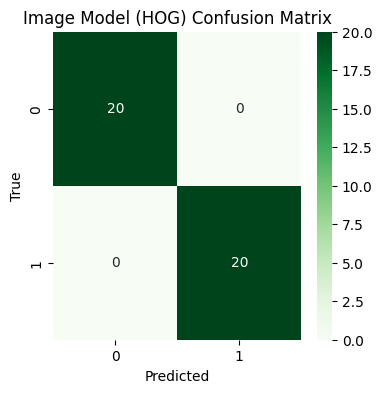

In [10]:
# =============================
# 2. IMAGE MODEL (PRIMARY) — HOG + SGDClassifier
# =============================


def load_image_paths(root: Path) -> List[Tuple[str, int]]:
    pairs: List[Tuple[str, int]] = []
    for label_name, label_int in [("ASD", 1), ("No_ASD", 0)]:
        class_dir = root / label_name
        if not class_dir.exists():
            continue
        for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp"):
            for p in class_dir.glob(ext):
                pairs.append((str(p), label_int))
    return pairs


def extract_hog_features(path: str) -> np.ndarray:
    img = Image.open(path).convert("RGB")
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
    gray = rgb2gray(np.asarray(img))
    return hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        transform_sqrt=True,
        feature_vector=True,
    )


image_pairs = load_image_paths(IMAGE_DATA_DIR)
print(f"Found {len(image_pairs)} images")

X_img = np.vstack([extract_hog_features(p) for p, _ in image_pairs])
y_img = np.array([lbl for _, lbl in image_pairs])

scaler_img = StandardScaler()
X_img_scaled = scaler_img.fit_transform(X_img)

X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    X_img_scaled, y_img, test_size=0.2, random_state=RANDOM_STATE, stratify=y_img
)

image_clf = SGDClassifier(loss="log_loss", max_iter=1000, random_state=RANDOM_STATE)
image_clf.fit(X_train_img, y_train_img)

y_pred_img = image_clf.predict(X_test_img)
print("Image accuracy:", accuracy_score(y_test_img, y_pred_img))
print("Image F1:", f1_score(y_test_img, y_pred_img, pos_label=1))
print(classification_report(y_test_img, y_pred_img, target_names=["No_ASD", "ASD"]))

cm_img = confusion_matrix(y_test_img, y_pred_img)
plt.figure(figsize=(4, 4))
sns.heatmap(cm_img, annot=True, fmt="d", cmap="Greens")
plt.title("Image Model (HOG) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [11]:
# =============================
# 3. TEXT MODEL
# =============================

text_df = pd.read_csv(TEXT_CSV_PATH)
print("Loaded text dataset:", text_df.shape)

X_text = text_df[TEXT_COLUMN]
y_text = text_df[TEXT_TARGET_COLUMN]

text_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=300, random_state=RANDOM_STATE)),
])

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text, y_text, test_size=0.2, random_state=RANDOM_STATE, stratify=y_text
)

text_pipeline.fit(X_train_text, y_train_text)

y_pred_text = text_pipeline.predict(X_test_text)
print("Text accuracy:", accuracy_score(y_test_text, y_pred_text))
print("Text F1:", f1_score(y_test_text, y_pred_text, pos_label=1))
print(classification_report(y_test_text, y_pred_text, target_names=["No_ASD", "ASD"]))

Loaded text dataset: (126, 2)
Text accuracy: 1.0
Text F1: 1.0
              precision    recall  f1-score   support

      No_ASD       1.00      1.00      1.00        13
         ASD       1.00      1.00      1.00        13

    accuracy                           1.00        26
   macro avg       1.00      1.00      1.00        26
weighted avg       1.00      1.00      1.00        26



In [12]:
# =============================
# 4. FUSION (IMAGE + TEXT)
# =============================


def predict_image_proba(image_path: str) -> float:
    feat = extract_hog_features(image_path).reshape(1, -1)
    feat = scaler_img.transform(feat)
    return float(image_clf.predict_proba(feat)[0, 1])


def combine_predictions(probas: Dict[str, float], method: str = "weighted") -> Dict[str, Any]:
    if not probas:
        raise ValueError("No modality probabilities provided")

    if method == "average":
        combined = float(np.mean(list(probas.values())))
        weights = {k: 1.0 / len(probas) for k in probas}
    elif method == "weighted":
        # Image-primary fusion
        base_weights = {"image": 0.65, "text": 0.35}
        used = {k: base_weights.get(k, 0.0) for k in probas}
        s = sum(used.values()) or 1.0
        weights = {k: v / s for k, v in used.items()}
        combined = float(sum(probas[k] * weights[k] for k in probas))
    elif method == "voting":
        votes = [1 if p >= 0.5 else 0 for p in probas.values()]
        majority = int(round(np.mean(votes)))
        combined = float(np.mean(list(probas.values())))
        weights = {k: 1.0 / len(probas) for k in probas}
        combined = max(combined, 0.51) if majority == 1 else min(combined, 0.49)
    else:
        avg = float(np.mean(list(probas.values())))
        combined = float(1.0 / (1.0 + np.exp(-5 * (avg - 0.5))))
        weights = {k: 1.0 / len(probas) for k in probas}

    label = "ASD" if combined >= 0.5 else "No ASD"
    risk = (
        "High ASD Risk" if combined >= 0.7
        else "Moderate ASD Risk" if combined >= 0.5
        else "Low ASD Risk"
    )
    return {"score": combined, "label": label, "risk": risk, "weights": weights}


def explain_final_prediction(score: float) -> str:
    if score >= 0.8:
        return "Very high likelihood of ASD-related traits; clinical evaluation strongly recommended."
    if score >= 0.6:
        return "Moderate to high likelihood; consider detailed clinical assessment."
    if score >= 0.4:
        return "Intermediate likelihood; result alone is not conclusive."
    return "Low estimated likelihood; clinical judgement is still essential."

FINAL PREDICTION: ASD
Risk level: High ASD Risk
Score: 0.9558
Per-modality: {'image': 1.0, 'text': 0.8736362421746986}
Weights: {'image': 0.65, 'text': 0.35}

Explanation:
 Very high likelihood of ASD-related traits; clinical evaluation strongly recommended.


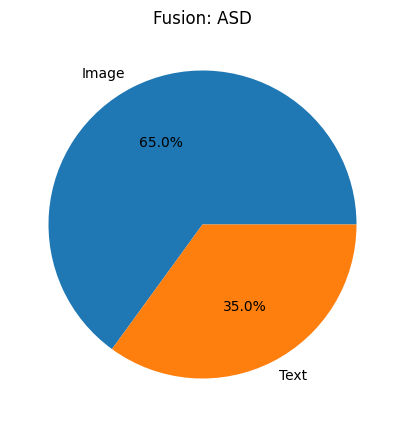

In [13]:
# =============================
# 5. USER INPUT — IMAGE + TEXT
# =============================


def predict_from_user_input(
    image_path: Optional[str],
    text_note: Optional[str],
    method: str = "weighted",
) -> Dict[str, Any]:
    probas: Dict[str, float] = {}

    if image_path and str(image_path).strip():
        probas["image"] = predict_image_proba(str(image_path))

    if text_note and str(text_note).strip():
        probas["text"] = float(text_pipeline.predict_proba([text_note])[0, 1])

    fusion = combine_predictions(probas, method=method)
    explanation = explain_final_prediction(fusion["score"])

    return {
        "per_modality": probas,
        "fusion": fusion,
        "explanation": explanation,
    }


# --- Edit these for your demo ---
example_image_path = str((IMAGE_DATA_DIR / "ASD" / "sample_000.jpg"))
example_text_note = "The child shows repetitive behavior and reduced eye contact."

result = predict_from_user_input(
    image_path=example_image_path,
    text_note=example_text_note,
    method="weighted",
)

print("=" * 50)
print("FINAL PREDICTION:", result["fusion"]["label"])
print("Risk level:", result["fusion"]["risk"])
print("Score:", round(result["fusion"]["score"], 4))
print("=" * 50)
print("Per-modality:", result["per_modality"])
print("Weights:", result["fusion"]["weights"])
print("\nExplanation:\n", result["explanation"])

# Contribution chart
if result["fusion"]["weights"]:
    labels = list(result["fusion"]["weights"].keys())
    vals = [result["fusion"]["weights"][k] for k in labels]
    plt.figure(figsize=(5, 5))
    plt.pie(vals, labels=[l.capitalize() for l in labels], autopct="%1.1f%%")
    plt.title(f"Fusion: {result['fusion']['label']}")
    plt.show()

In [14]:
# Compare fusion methods on the same input
for m in ["average", "weighted", "voting", "meta"]:
    r = predict_from_user_input(example_image_path, example_text_note, method=m)
    print(f"{m:10s} -> {r['fusion']['label']} (score={r['fusion']['score']:.3f})")

average    -> ASD (score=0.937)
weighted   -> ASD (score=0.956)
voting     -> ASD (score=0.937)
meta       -> ASD (score=0.899)


## Explainability

- **Image**: HOG captures edge/orientation patterns in the face region; higher weight (65%) in fusion because this project is image-primary.
- **Text**: Top TF-IDF terms with largest logistic-regression coefficients indicate which phrases push toward ASD vs No ASD.
- Replace synthetic faces in `asd_images/` with real labeled photos for stronger clinical relevance.

## Evaluation & Reporting

- **Image model**: HOG + SGDClassifier with accuracy, F1, confusion matrix.
- **Text model**: TF-IDF + Logistic Regression metrics.
- **Fusion**: Image-weighted combination of both modalities; compare `average`, `weighted`, `voting`, `meta` in the cell above.

**Note:** This is a screening aid, not a clinical diagnosis. Replace demo images with a real ASD face dataset when available.